## Phần 1: Khởi tạo môi trường và khám phá dữ liệu

### Bước 1: Khởi tạo SparkSession và nạp dữ liệu đã làm sạch từ HDFS

In [30]:
import os
import sys
import math
import findspark
os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable
findspark.init()
import pandas as pd
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import IntegerType
from pyspark.storagelevel import StorageLevel
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier, GBTClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator, TrainValidationSplit
from pyspark.ml.functions import vector_to_array

from sklearn.metrics import (
    f1_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve
)

spark = (
   SparkSession.builder
   .appName("Train_Model_Du_Doan_Mua_Hang")
   .master("spark://26.37.93.102:7077")
   .config("spark.executor.memory", "6g")
   .config("spark.executor.cores", "5")
   .config("spark.cores.max", "15")
   .config("spark.driver.memory", "5g")
   .config("spark.sql.shuffle.partitions", "30")
   .config("spark.default.parallelism", "30")
   .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer")
   .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR")

print("Đã tạo thành công kết nối SparkSession!")
df = spark.read.parquet("hdfs://master:9000/data/test_cleaned.parquet")
print(f"Tổng số dòng dữ liệu sẵn sàng cho mô hình: {df.count():,}")

Đã tạo thành công kết nối SparkSession!
Tổng số dòng dữ liệu sẵn sàng cho mô hình: 2,711,122


### Bước 2: Khám phá dữ liệu và kiểm tra phân phối nhãn

In [31]:
print("-" * 60)
print("THÔNG TIN SCHEMA")
print("-" * 60)
df.printSchema()

print("\n" + "-" * 60)
print("KIỂM TRA GIÁ TRỊ NULL TRONG TỪNG CỘT")
print("-" * 60)
df.select([F.sum(F.col(c).isNull().cast("int")).alias(c) for c in df.columns]).show(vertical=True)

print("\n" + "-" * 60)
print("PHÂN PHỐI LOẠI SỰ KIỆN (event_type)")
print("-" * 60)
df.groupBy("event_type").count().orderBy(F.desc("count")).show()

print("\n" + "-" * 60)
print("PHÂN PHỐI NHÃN MỤC TIÊU (target)")
print("-" * 60)
df.groupBy("target").count().orderBy("target").show()

print("\n" + "-" * 60)
print("THỐNG KÊ MÔ TẢ CỘT SỐ")
print("-" * 60)
df.select("price", "ts_hour", "ts_weekday").describe().show()

------------------------------------------------------------
THÔNG TIN SCHEMA
------------------------------------------------------------
root
 |-- product_id: string (nullable = true)
 |-- event_time: string (nullable = true)
 |-- event_type: string (nullable = true)
 |-- brand: string (nullable = true)
 |-- price: double (nullable = true)
 |-- user_id: string (nullable = true)
 |-- user_session: string (nullable = true)
 |-- target: long (nullable = true)
 |-- cat_0: string (nullable = true)
 |-- cat_1: string (nullable = true)
 |-- cat_2: string (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- ts_hour: short (nullable = true)
 |-- ts_minute: short (nullable = true)
 |-- ts_weekday: short (nullable = true)
 |-- ts_day: short (nullable = true)
 |-- ts_month: short (nullable = true)
 |-- ts_year: short (nullable = true)


------------------------------------------------------------
KIỂM TRA GIÁ TRỊ NULL TRONG TỪNG CỘT
-------------------------------------------------

---
## Phần 2: Tiền xử lý đặc trưng đầu vào

### Bước 3: Lọc dữ liệu và tạo nhãn

In [32]:
df_valid = (
    df
    .filter(
        (F.col("price") > 0) &
        F.col("timestamp").isNotNull() &
        F.col("product_id").isNotNull() &
        F.col("user_session").isNotNull() &
        F.col("event_type").isin("cart", "purchase")
    )
    .fillna({
        "brand":  "unknown",
        "cat_0":  "unknown",
        "cat_1":  "unknown",
        "cat_2":  "unknown",
    })
    .persist(StorageLevel.MEMORY_AND_DISK)
)

df_cart = (
    df_valid
    .filter(F.col("event_type") == "cart")
    .withColumnRenamed("timestamp", "cart_time")
)

df_purchase = (
    df_valid
    .filter(F.col("event_type") == "purchase")
    .select(
        "user_session",
        "product_id",
        F.col("timestamp").alias("purchase_time")
    )
)

df_session_start = (
    df_valid
    .groupBy("user_session")
    .agg(F.min("timestamp").alias("session_start"))
)

df_labeled = (
    df_cart
    .join(df_purchase, on=["user_session", "product_id"], how="left")
    .groupBy(
        "user_session", "product_id", "cart_time",
        "user_id", "price", "brand",
        "cat_0", "cat_1", "cat_2",
        "ts_hour", "ts_minute", "ts_weekday",
        "ts_day", "ts_month", "ts_year"
    )
    .agg(
        F.min(
            F.when(
                F.col("purchase_time") > F.col("cart_time"),
                F.col("purchase_time")
            )
        ).alias("first_purchase_after_cart")
    )
    .withColumn(
        "label",
        F.when(F.col("first_purchase_after_cart").isNotNull(), 1)
         .otherwise(0)
         .cast(IntegerType())
    )
    .withColumn(
        "seconds_to_purchase",
        F.when(
            F.col("first_purchase_after_cart").isNotNull(),
            F.col("first_purchase_after_cart").cast("long") - F.col("cart_time").cast("long")
        ).otherwise(F.lit(None).cast("long"))
    )
)

df_labeled = (
    df_labeled
    .join(df_session_start, on="user_session", how="left")
    .withColumn(
        "seconds_since_session_start",
        F.col("cart_time").cast("long") - F.col("session_start").cast("long")
    )
    .drop("session_start")
    .persist(StorageLevel.MEMORY_AND_DISK)
)

label_stats = (
    df_labeled
    .groupBy("label")
    .count()
    .collect()
)

stats = {row["label"]: row["count"] for row in label_stats}
total = sum(stats.values())
pos   = stats.get(1, 0)
neg   = stats.get(0, 0)

print("-" * 75)
print("THỐNG KÊ SAU KHI TẠO NHÃN: CART → PURCHASE TRONG CÙNG SESSION")
print("-" * 75)
print(f"Tổng số lần cart                                : {total:,}")
print(f"Label=1  (có purchase sau cart trong session)   : {pos:,}  ({pos/total*100:.4f}%)")
print(f"Label=0  (không có purchase sau cart)           : {neg:,}  ({neg/total*100:.4f}%)")
print(f"Tỷ lệ imbalance                                 : 1:{neg/pos:.2f}" if pos else "Không có Label=1 — kiểm tra lại dữ liệu")

print("\nMẫu dữ liệu sau khi tạo nhãn:")

# --- SỰ THAY ĐỔI DÀNH CHO JUPYTER ---
df_sample_pandas = (
    df_labeled
    .select(
        "user_session",
        "product_id",
        "cart_time",
        "first_purchase_after_cart",
        "brand",
        "cat_0", "cat_1", "cat_2",
        "price",
        "ts_hour", "ts_weekday",
        "seconds_to_purchase",
        "seconds_since_session_start",
        "label"
    )
    .limit(10)
    .toPandas()
)

display(df_sample_pandas)

---------------------------------------------------------------------------
THỐNG KÊ SAU KHI TẠO NHÃN: CART → PURCHASE TRONG CÙNG SESSION
---------------------------------------------------------------------------
Tổng số lần cart                                : 1,751,346
Label=1  (có purchase sau cart trong session)   : 6,046  (0.3452%)
Label=0  (không có purchase sau cart)           : 1,745,300  (99.6548%)
Tỷ lệ imbalance                                 : 1:288.67

Mẫu dữ liệu sau khi tạo nhãn:


,user_session,product_id,cart_time,first_purchase_after_cart,brand,cat_0,cat_1,cat_2,price,ts_hour,ts_weekday,seconds_to_purchase,seconds_since_session_start,label
0,000008b2-ca7f-49d2-a4d8-832453243111,1307319,2020-04-03 20:46:20,NaT,hp,electronics,audio,headphone,998.479980,13,4,NaN,0,0
1,00011dbe-53b7-469d-b75b-9e5fdc4be99f,2702611,2020-04-16 13:54:11,NaT,arg,appliances,kitchen,refrigerators,141.550003,6,3,NaN,0,0
2,0001f33f-1e31-4576-bdc1-183a9d4b97f1,1201567,2020-04-22 10:42:33,NaT,apple,apparel,shoes,slipons,395.869995,3,2,NaN,1,0
3,0001f33f-1e31-4576-bdc1-183a9d4b97f1,1201567,2020-04-22 10:42:32,NaT,apple,apparel,shoes,slipons,395.869995,3,2,NaN,0,0
4,00077295-4559-44b2-a364-985555816cc3,100084224,2020-04-24 18:02:09,NaT,arg,appliances,personal,hair_cutter,12.840000,11,4,NaN,0,0
5,000df2b7-8476-4958-9dc6-15a8464d1b7e,5100851,2020-04-03 16:13:54,NaT,honor,apparel,shoes,unknown,51.459999,9,4,NaN,0,0
6,000e81d6-5367-4716-961d-40520484602b,12201879,2020-04-21 11:25:51,NaT,unknown,appliances,kitchen,toster,69.470001,4,1,NaN,0,0
7,0011ea99-3012-4e4e-b7e9-fb42c1a284b5,8700085,2020-04-08 22:52:43,NaT,vitek,appliances,personal,hair_cutter,20.570000,15,2,NaN,0,0
8,0014afce-38e8-4174-ae29-cc35f6a5177d,100005682,2020-04-22 02:42:16,NaT,xiaomi,construction,tools,light,334.600006,19,1,NaN,0,0
9,0014d71d-272e-4481-9d87-19b1b16f670c,100000900,2020-04-05 21:30:45,NaT,delta,computers,peripherals,printer,181.470001,14,6,NaN,0,0


### Bước 4: Tạo đặc trưng mới

In [33]:
df_feat = df_labeled \
    .withColumn(
        "price_log",
        F.log1p(F.col("price"))
    ) \
    .withColumn(
        "is_golden_hour",
        F.when(
            (F.col("ts_hour").between(10, 12)) | (F.col("ts_hour").between(20, 22)), 1
        ).otherwise(0).cast(IntegerType())
    ) \
    .withColumn(
        "session_part",
        F.when(F.col("ts_hour").between(0, 5), "night")
         .when(F.col("ts_hour").between(6, 11), "morning")
         .when(F.col("ts_hour").between(12, 17), "afternoon")
         .otherwise("evening")
    ) \
    .withColumn(
        "time_spent_log",
        F.log1p(F.col("seconds_since_session_start")) # Xử lý lệch chuẩn cho thời gian lướt web
    )

print("Các đặc trưng sẵn sàng đưa vào pipeline mô hình:")

df_show_feat = df_feat.select(
    "label",
    "price_log",
    "time_spent_log",
    "session_part",
    "is_golden_hour",
    "brand",
    "cat_0",
    "ts_weekday"
).limit(10).toPandas()

display(df_show_feat)

Các đặc trưng sẵn sàng đưa vào pipeline mô hình:


,label,price_log,time_spent_log,session_part,is_golden_hour,brand,cat_0,ts_weekday
0,0,6.907235,0.000000,afternoon,0,hp,electronics,4
1,0,4.959693,0.000000,morning,0,arg,appliances,3
2,0,5.983609,0.693147,night,0,apple,apparel,2
3,0,5.983609,0.000000,night,0,apple,apparel,2
4,0,2.627563,0.000000,morning,1,arg,appliances,4
5,0,3.960051,0.000000,morning,0,honor,apparel,4
6,0,4.255187,0.000000,night,0,unknown,appliances,1
7,0,3.071303,0.000000,afternoon,0,vitek,appliances,2
8,0,5.815920,0.000000,evening,0,xiaomi,construction,1
9,0,5.206586,0.000000,afternoon,0,delta,computers,6


### Bước 5: Xây dựng Spark ML Pipeline

In [34]:
cat_cols     = ["brand", "cat_0", "session_part", "ts_weekday"]
numeric_cols = ["price_log", "is_golden_hour", "time_spent_log"]
indexed_cols = [c + "_idx" for c in cat_cols]
encoded_cols = [c + "_ohe" for c in cat_cols]

indexers = [
    StringIndexer(inputCol=c, outputCol=c + "_idx", handleInvalid="keep")
    for c in cat_cols
]

encoder = OneHotEncoder(
    inputCols=indexed_cols,
    outputCols=encoded_cols,
    dropLast=True
)

all_feature_cols = numeric_cols + encoded_cols

assembler = VectorAssembler(
    inputCols=all_feature_cols,
    outputCol="features_raw",
    handleInvalid="keep"
)

scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features",
    withMean=False,
    withStd=True
)

print("Đã định nghĩa các bước tiền xử lý trong Pipeline:")
print(f"   Categorical (OHE): {cat_cols}")
print(f"   Numeric          : {numeric_cols}")
print(f"   Tổng số nhóm đặc trưng gốc: {len(all_feature_cols)} (sẽ bung rộng sau OneHot)")

Đã định nghĩa các bước tiền xử lý trong Pipeline:
   Categorical (OHE): ['brand', 'cat_0', 'session_part', 'ts_weekday']
   Numeric          : ['price_log', 'is_golden_hour', 'time_spent_log']
   Tổng số nhóm đặc trưng gốc: 7 (sẽ bung rộng sau OneHot)


### Bước 6: Phân chia tập Train/ Test & xử lý mất cân bằng lớp

In [35]:
all_sessions = df_feat.select("user_session").distinct()
train_sess, val_sess, test_sess = all_sessions.randomSplit([0.7, 0.15, 0.15], seed=42)

train_df_full = df_feat.join(F.broadcast(train_sess), on="user_session", how="inner")
val_df_full = df_feat.join(F.broadcast(val_sess), on="user_session", how="inner")
test_df_full = df_feat.join(F.broadcast(test_sess), on="user_session", how="inner")

train_pos = train_df_full.filter(F.col("label") == 1)
train_neg = train_df_full.filter(F.col("label") == 0)

pos_train_count = train_pos.count()
neg_train_count = train_neg.count()

TARGET_RATIO = 10
fraction = min(1.0, (pos_train_count * TARGET_RATIO) / neg_train_count)

train_neg_sampled = train_neg.sample(withReplacement=False, fraction=fraction, seed=42)

train_df = (
    train_pos.union(train_neg_sampled)
    .repartition(30, F.rand(seed=42))
    .persist(StorageLevel.MEMORY_AND_DISK)
)

val_df = val_df_full.persist(StorageLevel.MEMORY_AND_DISK)
test_df = test_df_full.persist(StorageLevel.MEMORY_AND_DISK)

train_stats = {r["label"]: r["count"] for r in train_df.groupBy("label").count().collect()}
val_stats = {r["label"]: r["count"] for r in val_df.groupBy("label").count().collect()}
test_stats = {r["label"]: r["count"] for r in test_df.groupBy("label").count().collect()}

pos_train_c = train_stats.get(1, 0)
neg_train_c = train_stats.get(0, 0)
train_total = pos_train_c + neg_train_c

pos_val_c = val_stats.get(1, 0)
neg_val_c = val_stats.get(0, 0)
val_total = pos_val_c + neg_val_c

pos_test_c = test_stats.get(1, 0)
neg_test_c = test_stats.get(0, 0)
test_total = pos_test_c + neg_test_c

print("=" * 65)
print("THỐNG KÊ TẬP TRAIN (ĐÃ UNDERSAMPLING)")
print("=" * 65)
print(f"Tổng số dòng         : {train_total:,}")
print(f"Label = 1            : {pos_train_c:,}")
print(f"Label = 0            : {neg_train_c:,}")
print(f"Tỷ lệ thực tế        : 1:{neg_train_c/pos_train_c:.2f}" if pos_train_c else "N/A")

print("\n" + "=" * 65)
print("THỐNG KÊ TẬP VALIDATION (GIỮ NGUYÊN PHÂN PHỐI THỰC TẾ)")
print("=" * 65)
print(f"Tổng số dòng         : {val_total:,}")
print(f"Label = 1            : {pos_val_c:,}  ({pos_val_c/val_total*100:.4f}%)")
print(f"Label = 0            : {neg_val_c:,}  ({neg_val_c/val_total*100:.4f}%)")
print(f"Tỷ lệ thực tế        : 1:{neg_val_c/pos_val_c:.2f}" if pos_val_c else "N/A")

print("\n" + "=" * 65)
print("THỐNG KÊ TẬP TEST (GIỮ NGUYÊN PHÂN PHỐI THỰC TẾ)")
print("=" * 65)
print(f"Tổng số dòng         : {test_total:,}")
print(f"Label = 1            : {pos_test_c:,}  ({pos_test_c/test_total*100:.4f}%)")
print(f"Label = 0            : {neg_test_c:,}  ({neg_test_c/test_total*100:.4f}%)")
print(f"Tỷ lệ thực tế        : 1:{neg_test_c/pos_test_c:.2f}" if pos_test_c else "N/A")

THỐNG KÊ TẬP TRAIN (ĐÃ UNDERSAMPLING)
Tổng số dòng         : 48,224
Label = 1            : 4,350
Label = 0            : 43,874
Tỷ lệ thực tế        : 1:10.09

THỐNG KÊ TẬP VALIDATION (GIỮ NGUYÊN PHÂN PHỐI THỰC TẾ)
Tổng số dòng         : 262,551
Label = 1            : 868  (0.3306%)
Label = 0            : 261,683  (99.6694%)
Tỷ lệ thực tế        : 1:301.48

THỐNG KÊ TẬP TEST (GIỮ NGUYÊN PHÂN PHỐI THỰC TẾ)
Tổng số dòng         : 263,163
Label = 1            : 828  (0.3146%)
Label = 0            : 262,335  (99.6854%)
Tỷ lệ thực tế        : 1:316.83


---
## Phần 3: Đào tạo và Đánh giá Mô hình

### Bước 7: Huấn luyện mô hình Logistic Regression

In [39]:
prep_pipeline = Pipeline(stages=indexers + [encoder, assembler, scaler])
prep_model    = prep_pipeline.fit(train_df)

train_with_meta = (
    prep_model.transform(train_df)
    .persist(StorageLevel.MEMORY_AND_DISK)
)

FEATURE_ATTRS = train_with_meta.schema["features_raw"].metadata["ml_attr"]["attrs"]

train_prepared = (
    train_with_meta
    .select("features", "label")
    .persist(StorageLevel.MEMORY_ONLY)
)

val_prepared = (
    prep_model.transform(val_df)
    .select("features", "label")
    .persist(StorageLevel.MEMORY_ONLY)
)

test_prepared = (
    prep_model.transform(test_df)
    .select("features", "label")
    .persist(StorageLevel.MEMORY_ONLY)
)

lr = LogisticRegression(
    labelCol="label",
    featuresCol="features",
    maxIter=100,
    family="binomial",
    standardization=False
)

paramGrid_lr = (
    ParamGridBuilder()
    .addGrid(lr.regParam,        [0.01, 0.1, 1.0])
    .addGrid(lr.elasticNetParam, [0.0,  0.5, 1.0])
    .build()
)

evaluator_cv = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

cv_lr = CrossValidator(
    estimator=lr,
    estimatorParamMaps=paramGrid_lr,
    evaluator=evaluator_cv,
    numFolds=3,
    parallelism=3,
    collectSubModels=False,
    seed=42
)

print("Đang huấn luyện Logistic Regression...")
cvModel_lr = cv_lr.fit(train_prepared)
print("Huấn luyện hoàn tất!")

best_lr = cvModel_lr.bestModel
print(f"regParam tốt nhất       : {best_lr.getRegParam()}")
print(f"elasticNetParam tốt nhất: {best_lr.getElasticNetParam()}")

print("\nROC-AUC theo từng tổ hợp tham số:")
for params, score in zip(paramGrid_lr, cvModel_lr.avgMetrics):
    reg     = params[lr.regParam]
    elastic = params[lr.elasticNetParam]
    print(f"  regParam={reg:<5} elasticNetParam={elastic:<4} → ROC-AUC={score:.4f}")

Đang huấn luyện Logistic Regression...
Huấn luyện hoàn tất!
regParam tốt nhất       : 0.01
elasticNetParam tốt nhất: 0.0

ROC-AUC theo từng tổ hợp tham số:
  regParam=0.01  elasticNetParam=0.0  → ROC-AUC=0.6542
  regParam=0.01  elasticNetParam=0.5  → ROC-AUC=0.6310
  regParam=0.01  elasticNetParam=1.0  → ROC-AUC=0.6130
  regParam=0.1   elasticNetParam=0.0  → ROC-AUC=0.6529
  regParam=0.1   elasticNetParam=0.5  → ROC-AUC=0.5000
  regParam=0.1   elasticNetParam=1.0  → ROC-AUC=0.5000
  regParam=1.0   elasticNetParam=0.0  → ROC-AUC=0.6502
  regParam=1.0   elasticNetParam=0.5  → ROC-AUC=0.5000
  regParam=1.0   elasticNetParam=1.0  → ROC-AUC=0.5000


### Bước 8: Huấn luyện mô hình Random Forest Classifier

In [40]:
rf = RandomForestClassifier(
    labelCol="label",
    featuresCol="features",
    minInstancesPerNode=10,
    featureSubsetStrategy="sqrt",
    seed=42
)

paramGrid_rf = (
    ParamGridBuilder()
    .addGrid(rf.maxDepth, [5, 8, 10])
    .addGrid(rf.numTrees, [50, 100])
    .addGrid(rf.maxBins,  [32, 64])
    .build()
)

evaluator_cv = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

cv_rf = CrossValidator(
    estimator=rf,
    estimatorParamMaps=paramGrid_rf,
    evaluator=evaluator_cv,
    numFolds=3,
    parallelism=4,
    seed=42
)

print("Đang tìm tham số tối ưu và huấn luyện Random Forest...")
cvModel_rf = cv_rf.fit(train_prepared)
print("Huấn luyện Random Forest hoàn tất!")

best_rf = cvModel_rf.bestModel
print(f"maxDepth tốt nhất : {best_rf.getMaxDepth()}")
print(f"numTrees tốt nhất : {best_rf.getNumTrees}")
print(f"maxBins tốt nhất  : {best_rf.getMaxBins()}")

print("\nROC-AUC theo từng tổ hợp tham số:")
for params, score in zip(paramGrid_rf, cvModel_rf.avgMetrics):
    depth = params[rf.maxDepth]
    trees = params[rf.numTrees]
    bins  = params[rf.maxBins]
    print(f"  maxDepth={depth:<2} numTrees={trees:<3} maxBins={bins:<3} → ROC-AUC={score:.4f}")

attrs = FEATURE_ATTRS

flat_features = (
    attrs.get("numeric", []) +
    attrs.get("binary", [])  +
    attrs.get("nominal", [])
)

importance_df = (
    pd.DataFrame({
        "feature":    [f["name"] for f in flat_features],
        "importance": best_rf.featureImportances.toArray()
    })
    .sort_values("importance", ascending=False)
    .head(10)
)

print("\nTop 10 feature quan trọng nhất (Random Forest):")
print(importance_df.to_string(index=False))

Đang tìm tham số tối ưu và huấn luyện Random Forest...
Huấn luyện Random Forest hoàn tất!
maxDepth tốt nhất : 8
numTrees tốt nhất : 100
maxBins tốt nhất  : 64

ROC-AUC theo từng tổ hợp tham số:
  maxDepth=5  numTrees=50  maxBins=32  → ROC-AUC=0.5939
  maxDepth=5  numTrees=50  maxBins=64  → ROC-AUC=0.6003
  maxDepth=5  numTrees=100 maxBins=32  → ROC-AUC=0.6127
  maxDepth=5  numTrees=100 maxBins=64  → ROC-AUC=0.6261
  maxDepth=8  numTrees=50  maxBins=32  → ROC-AUC=0.6295
  maxDepth=8  numTrees=50  maxBins=64  → ROC-AUC=0.6066
  maxDepth=8  numTrees=100 maxBins=32  → ROC-AUC=0.6284
  maxDepth=8  numTrees=100 maxBins=64  → ROC-AUC=0.6371
  maxDepth=10 numTrees=50  maxBins=32  → ROC-AUC=0.6348
  maxDepth=10 numTrees=50  maxBins=64  → ROC-AUC=0.6175
  maxDepth=10 numTrees=100 maxBins=32  → ROC-AUC=0.6303
  maxDepth=10 numTrees=100 maxBins=64  → ROC-AUC=0.6350

Top 10 feature quan trọng nhất (Random Forest):
                 feature  importance
          brand_ohe_bork    0.143858
          t

### Bước 9: Huấn luyện mô hình Gradient-Boosted Trees (GBT)

In [41]:
gbt = GBTClassifier(
   labelCol="label",
   featuresCol="features",
   subsamplingRate=0.8,
   featureSubsetStrategy="sqrt",
   maxBins=32,
   seed=42
)

paramGrid_gbt = (
   ParamGridBuilder()
   .addGrid(gbt.maxDepth, [4, 6, 8])
   .addGrid(gbt.stepSize, [0.05, 0.1])
   .addGrid(gbt.maxIter,  [50, 100])
   .build()
)

evaluator_cv = BinaryClassificationEvaluator(
   labelCol="label",
   rawPredictionCol="rawPrediction",
   metricName="areaUnderROC"
)

tvs_gbt = TrainValidationSplit(
   estimator=gbt,
   estimatorParamMaps=paramGrid_gbt,
   evaluator=evaluator_cv,
   trainRatio=0.8,
   parallelism=4,
   seed=42
)

print("Đang huấn luyện GBT...")
tvsModel_gbt = tvs_gbt.fit(train_prepared)
print("Huấn luyện GBT hoàn tất!")

best_gbt = tvsModel_gbt.bestModel
print(f"maxDepth tốt nhất : {best_gbt.getMaxDepth()}")
print(f"maxIter tốt nhất  : {best_gbt.getMaxIter()}")
print(f"stepSize tốt nhất : {best_gbt.getStepSize()}")

print("\nROC-AUC theo từng tổ hợp tham số (trên tập Validation nội bộ):")
for params, score in zip(paramGrid_gbt, tvsModel_gbt.validationMetrics):
   depth = params[gbt.maxDepth]
   iters = params[gbt.maxIter]
   step  = params[gbt.stepSize]
   print(f"  maxDepth={depth:<2} maxIter={iters:<3} stepSize={step:<5} → ROC-AUC={score:.4f}")

attrs_gbt = FEATURE_ATTRS

flat_features_gbt = (
   attrs_gbt.get("numeric", []) +
   attrs_gbt.get("binary",  []) +
   attrs_gbt.get("nominal", [])
)

importance_df_gbt = (
   pd.DataFrame({
       "feature":    [f["name"] for f in flat_features_gbt],
       "importance": best_gbt.featureImportances.toArray()
   })
   .sort_values("importance", ascending=False)
   .head(10)
)

print("\nTop 10 feature quan trọng nhất (GBT):")
print(importance_df_gbt.to_string(index=False))

Đang huấn luyện GBT...
Huấn luyện GBT hoàn tất!
maxDepth tốt nhất : 8
maxIter tốt nhất  : 100
stepSize tốt nhất : 0.1

ROC-AUC theo từng tổ hợp tham số (trên tập Validation nội bộ):
  maxDepth=4  maxIter=50  stepSize=0.05  → ROC-AUC=0.6345
  maxDepth=4  maxIter=100 stepSize=0.05  → ROC-AUC=0.6407
  maxDepth=4  maxIter=50  stepSize=0.1   → ROC-AUC=0.6396
  maxDepth=4  maxIter=100 stepSize=0.1   → ROC-AUC=0.6452
  maxDepth=6  maxIter=50  stepSize=0.05  → ROC-AUC=0.6467
  maxDepth=6  maxIter=100 stepSize=0.05  → ROC-AUC=0.6508
  maxDepth=6  maxIter=50  stepSize=0.1   → ROC-AUC=0.6532
  maxDepth=6  maxIter=100 stepSize=0.1   → ROC-AUC=0.6590
  maxDepth=8  maxIter=50  stepSize=0.05  → ROC-AUC=0.6562
  maxDepth=8  maxIter=100 stepSize=0.05  → ROC-AUC=0.6614
  maxDepth=8  maxIter=50  stepSize=0.1   → ROC-AUC=0.6577
  maxDepth=8  maxIter=100 stepSize=0.1   → ROC-AUC=0.6642

Top 10 feature quan trọng nhất (GBT):
                   feature  importance
            time_spent_log    0.220215
     

### Bước 10: Sinh xác suất dự đoán

In [42]:
print("=" * 80)
print("BƯỚC 10: SINH XÁC SUẤT DỰ ĐOÁN TRÊN TẬP VALIDATION VÀ TẬP TEST")
print("=" * 80)

val_pred_lr  = best_lr.transform(val_prepared)
val_pred_rf  = best_rf.transform(val_prepared)
val_pred_gbt = best_gbt.transform(val_prepared)

test_pred_lr  = best_lr.transform(test_prepared)
test_pred_rf  = best_rf.transform(test_prepared)
test_pred_gbt = best_gbt.transform(test_prepared)

print("Đã hoàn tất sinh xác suất cho cả 3 thuật toán.\n")
print("MẪU KẾT QUẢ ĐỐI VỚI KHÁCH HÀNG THỰC SỰ MUA HÀNG (LABEL = 1) TRÊN TẬP TEST:")
print("\n")

cols_to_show = ["label", "probability", "prediction"]

print("[1. Logistic Regression]")
test_pred_lr.filter(F.col("label") == 1).select(cols_to_show).limit(3).show(truncate=False)

print("[2. Random Forest]")
test_pred_rf.filter(F.col("label") == 1).select(cols_to_show).limit(3).show(truncate=False)

print("[3. GBT]")
test_pred_gbt.filter(F.col("label") == 1).select(cols_to_show).limit(3).show(truncate=False)

BƯỚC 10: SINH XÁC SUẤT DỰ ĐOÁN TRÊN TẬP VALIDATION VÀ TẬP TEST
Đã hoàn tất sinh xác suất cho cả 3 thuật toán.

MẪU KẾT QUẢ ĐỐI VỚI KHÁCH HÀNG THỰC SỰ MUA HÀNG (LABEL = 1) TRÊN TẬP TEST:


[1. Logistic Regression]
+-----+-----------------------------------------+----------+
|label|probability                              |prediction|
+-----+-----------------------------------------+----------+
|1    |[0.966606403705163,0.03339359629483696]  |0.0       |
|1    |[0.9754658844264702,0.024534115573529802]|0.0       |
|1    |[0.9337496167296517,0.06625038327034827] |0.0       |
+-----+-----------------------------------------+----------+

[2. Random Forest]
+-----+----------------------------------------+----------+
|label|probability                             |prediction|
+-----+----------------------------------------+----------+
|1    |[0.9127157447094751,0.0872842552905249] |0.0       |
|1    |[0.9129142289349771,0.08708577106502295]|0.0       |
|1    |[0.9102800849150348,0.08971991508

### Bước 11: Tìm ngưỡng (Threshold) tối ưu cho 3 mô hình

In [43]:
def find_best_threshold(df_pred, model_name):
    print(f"Đang quét tìm Threshold tối ưu cho {model_name}...")

    prob_and_label = df_pred.withColumn("prob_1", vector_to_array("probability")[1]) \
                            .select("prob_1", "label").toPandas()

    y_true = prob_and_label["label"]
    y_probs = prob_and_label["prob_1"]

    best_threshold = 0.50
    best_f1 = 0.0

    for thresh in np.arange(0.01, 1.01, 0.01):
        y_pred_tmp = (y_probs >= thresh).astype(int)
        current_f1 = f1_score(y_true, y_pred_tmp, zero_division=0)
        if current_f1 > best_f1:
            best_f1 = current_f1
            best_threshold = round(thresh, 2)

    print(f"-> [TỐI ƯU] {model_name}: Threshold = {best_threshold} (F1 cao nhất: {best_f1:.4f})\n")
    return best_threshold

thresh_lr = find_best_threshold(val_pred_lr, "Logistic Regression")
thresh_rf = find_best_threshold(val_pred_rf, "Random Forest")
thresh_gbt = find_best_threshold(val_pred_gbt, "Gradient-Boosted Trees")

Đang quét tìm Threshold tối ưu cho Logistic Regression...
-> [TỐI ƯU] Logistic Regression: Threshold = 0.22 (F1 cao nhất: 0.0175)

Đang quét tìm Threshold tối ưu cho Random Forest...
-> [TỐI ƯU] Random Forest: Threshold = 0.1 (F1 cao nhất: 0.0178)

Đang quét tìm Threshold tối ưu cho Gradient-Boosted Trees...
-> [TỐI ƯU] Gradient-Boosted Trees: Threshold = 0.16 (F1 cao nhất: 0.0240)



### Bước 12: Áp dụng ngưỡng tối ưu tương ứng cho mỗi mô hình

In [44]:
def apply_threshold(df, threshold):
    return df.withColumn("prob_1", vector_to_array(F.col("probability"))[1]) \
             .withColumn("prediction_tuned",
                         F.when(F.col("prob_1") >= threshold, 1.0).otherwise(0.0))

test_pred_lr_tuned = apply_threshold(test_pred_lr, thresh_lr)
test_pred_rf_tuned = apply_threshold(test_pred_rf, thresh_rf)
test_pred_gbt_tuned = apply_threshold(test_pred_gbt, thresh_gbt)

print("Đã hoàn tất việc gán Threshold riêng biệt cho 3 mô hình trên tập Test!")

Đã hoàn tất việc gán Threshold riêng biệt cho 3 mô hình trên tập Test!


### Bước 13: Đánh giá mô hình - ROC-AUC, F1, Precision, Recall, MCC

In [45]:
def evaluate_model_comprehensive(df_tuned, model_name, applied_thresh):
    print(f"--- ĐÁNH GIÁ MÔ HÌNH: {model_name} (Threshold = {applied_thresh}) ---")

    spark_eval_roc = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
    spark_eval_pr  = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderPR")

    spark_eval_multi = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction_tuned")

    spark_roc_auc = spark_eval_roc.evaluate(df_tuned)
    spark_pr_auc  = spark_eval_pr.evaluate(df_tuned)

    spark_eval_multi.setMetricName("accuracy")
    spark_acc = spark_eval_multi.evaluate(df_tuned)

    spark_eval_multi.setMetricName("f1")
    spark_f1 = spark_eval_multi.evaluate(df_tuned)

    print("[Spark MLlib Metrics]")
    print(f"  • Accuracy : {spark_acc:.4f}")
    print(f"  • F1-Score : {spark_f1:.4f}")
    print(f"  • ROC-AUC  : {spark_roc_auc:.4f}")
    print(f"  • PR-AUC   : {spark_pr_auc:.4f}\n")

    pd_df = df_tuned.select("label", "prediction_tuned").toPandas()
    y_true = pd_df["label"]
    y_pred = pd_df["prediction_tuned"]

    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0

    mcc_num = (tp * tn) - (fp * fn)
    mcc_den = math.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
    mcc = mcc_num / mcc_den if mcc_den > 0 else 0.0

    print("[Sklearn Detailed Metrics]")
    print("Confusion Matrix:")
    print(f"[{tn:6} {fp:6}]\n[{fn:6} {tp:6}]")
    print(f"  • Precision: {precision:.4f}")
    print(f"  • Recall   : {recall:.4f}")
    print(f"  • MCC      : {mcc:.4f}")
    print("="*70 + "\n")

    return {
        "Model": model_name,
        "PR-AUC": spark_pr_auc,
        "ROC-AUC": spark_roc_auc,
        "MCC": mcc,
        "F1": spark_f1,
        "Precision": precision,
        "Recall": recall
    }

metrics_lr  = evaluate_model_comprehensive(test_pred_lr_tuned, "Logistic Regression", thresh_lr)
metrics_rf  = evaluate_model_comprehensive(test_pred_rf_tuned, "Random Forest", thresh_rf)
metrics_gbt = evaluate_model_comprehensive(test_pred_gbt_tuned, "Gradient-Boosted Trees", thresh_gbt)

--- ĐÁNH GIÁ MÔ HÌNH: Logistic Regression (Threshold = 0.22) ---
[Spark MLlib Metrics]
  • Accuracy : 0.9788
  • F1-Score : 0.9862
  • ROC-AUC  : 0.5851
  • PR-AUC   : 0.0044

[Sklearn Detailed Metrics]
Confusion Matrix:
[257555   4780]
[   797     31]
  • Precision: 0.0064
  • Recall   : 0.0374
  • MCC      : 0.0080

--- ĐÁNH GIÁ MÔ HÌNH: Random Forest (Threshold = 0.1) ---
[Spark MLlib Metrics]
  • Accuracy : 0.9863
  • F1-Score : 0.9900
  • ROC-AUC  : 0.5901
  • PR-AUC   : 0.0043

[Sklearn Detailed Metrics]
Confusion Matrix:
[259537   2798]
[   808     20]
  • Precision: 0.0071
  • Recall   : 0.0242
  • MCC      : 0.0073

--- ĐÁNH GIÁ MÔ HÌNH: Gradient-Boosted Trees (Threshold = 0.16) ---
[Spark MLlib Metrics]
  • Accuracy : 0.9649
  • F1-Score : 0.9791
  • ROC-AUC  : 0.6044
  • PR-AUC   : 0.0048

[Sklearn Detailed Metrics]
Confusion Matrix:
[253857   8478]
[   769     59]
  • Precision: 0.0069
  • Recall   : 0.0713
  • MCC      : 0.0123



### Bước 14: So sánh ba mô hình

In [46]:
print("=" * 80)
print("BƯỚC 14: TỔNG HỢP VÀ SO SÁNH BA MÔ HÌNH")
print("=" * 80)

comparison_data = [metrics_lr, metrics_rf, metrics_gbt]
comparison_df = pd.DataFrame(comparison_data)

cols_order = ["Model", "PR-AUC", "ROC-AUC", "MCC", "F1", "Precision", "Recall"]
comparison_df = comparison_df[cols_order]

metric_cols = ["PR-AUC", "ROC-AUC", "MCC", "F1", "Precision", "Recall"]
comparison_df[metric_cols] = comparison_df[metric_cols].round(4)

print("\n BẢNG CHỈ SỐ CHI TIẾT:")
display(comparison_df)

# Tìm mô hình tốt nhất dựa trên PR-AUC
best_model = max(comparison_data, key=lambda x: x["PR-AUC"])

print("\n KẾT LUẬN MÔ HÌNH TỐT NHẤT:")
print(f"Mô hình chiến thắng: {best_model['Model'].upper()}")
print(f"Lý do: Đạt PR-AUC cao nhất ({best_model['PR-AUC']:.4f}).")
print("Đối với bài toán mất cân bằng dữ liệu cực độ (1:288), PR-AUC là thước đo")
print("chính xác nhất để đánh giá khả năng mô hình bắt trúng khách hàng sẽ mua sản phẩm.")

BƯỚC 14: TỔNG HỢP VÀ SO SÁNH BA MÔ HÌNH

 BẢNG CHỈ SỐ CHI TIẾT:


,Model,PR-AUC,ROC-AUC,MCC,F1,Precision,Recall
0,Logistic Regression,0.0044,0.5851,0.0080,0.9862,0.0064,0.0374
1,Random Forest,0.0043,0.5901,0.0073,0.9900,0.0071,0.0242
2,Gradient-Boosted Trees,0.0048,0.6044,0.0123,0.9791,0.0069,0.0713



 KẾT LUẬN MÔ HÌNH TỐT NHẤT:
Mô hình chiến thắng: GRADIENT-BOOSTED TREES
Lý do: Đạt PR-AUC cao nhất (0.0048).
Đối với bài toán mất cân bằng dữ liệu cực độ (1:288), PR-AUC là thước đo
chính xác nhất để đánh giá khả năng mô hình bắt trúng khách hàng sẽ mua sản phẩm.


---
## Phần 4: Trực quan hóa mô hình

### Bước 15: Feature Importance - Gradient-Boosted Trees (GBT)

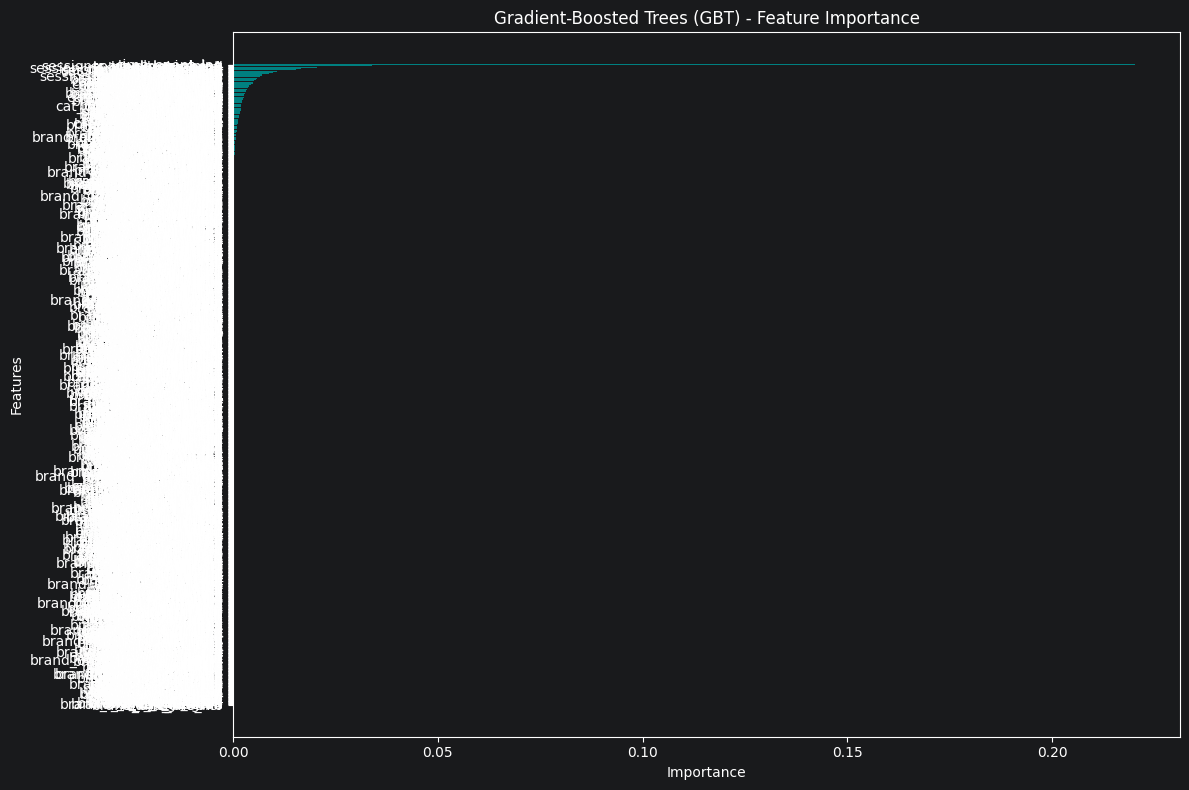

In [47]:
gbt_model = best_gbt
importances = gbt_model.featureImportances.toArray()

attrs = FEATURE_ATTRS
feature_names = (
    [x["name"] for x in attrs.get("numeric", [])] +
    [x["name"] for x in attrs.get("binary",  [])] +
    [x["name"] for x in attrs.get("nominal", [])]
)

if len(feature_names) != len(importances):
    feature_names = [f"Feature_{i}" for i in range(len(importances))]

feat_imp_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(12, 8))
plt.barh(feat_imp_df["Feature"], feat_imp_df["Importance"], color="teal")
plt.gca().invert_yaxis()
plt.title("Gradient-Boosted Trees (GBT) - Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

### Bước 16: Vẽ toàn bộ biểu đồ đánh giá mô hình

BƯỚC 16: TRỰC QUAN HÓA TOÀN DIỆN


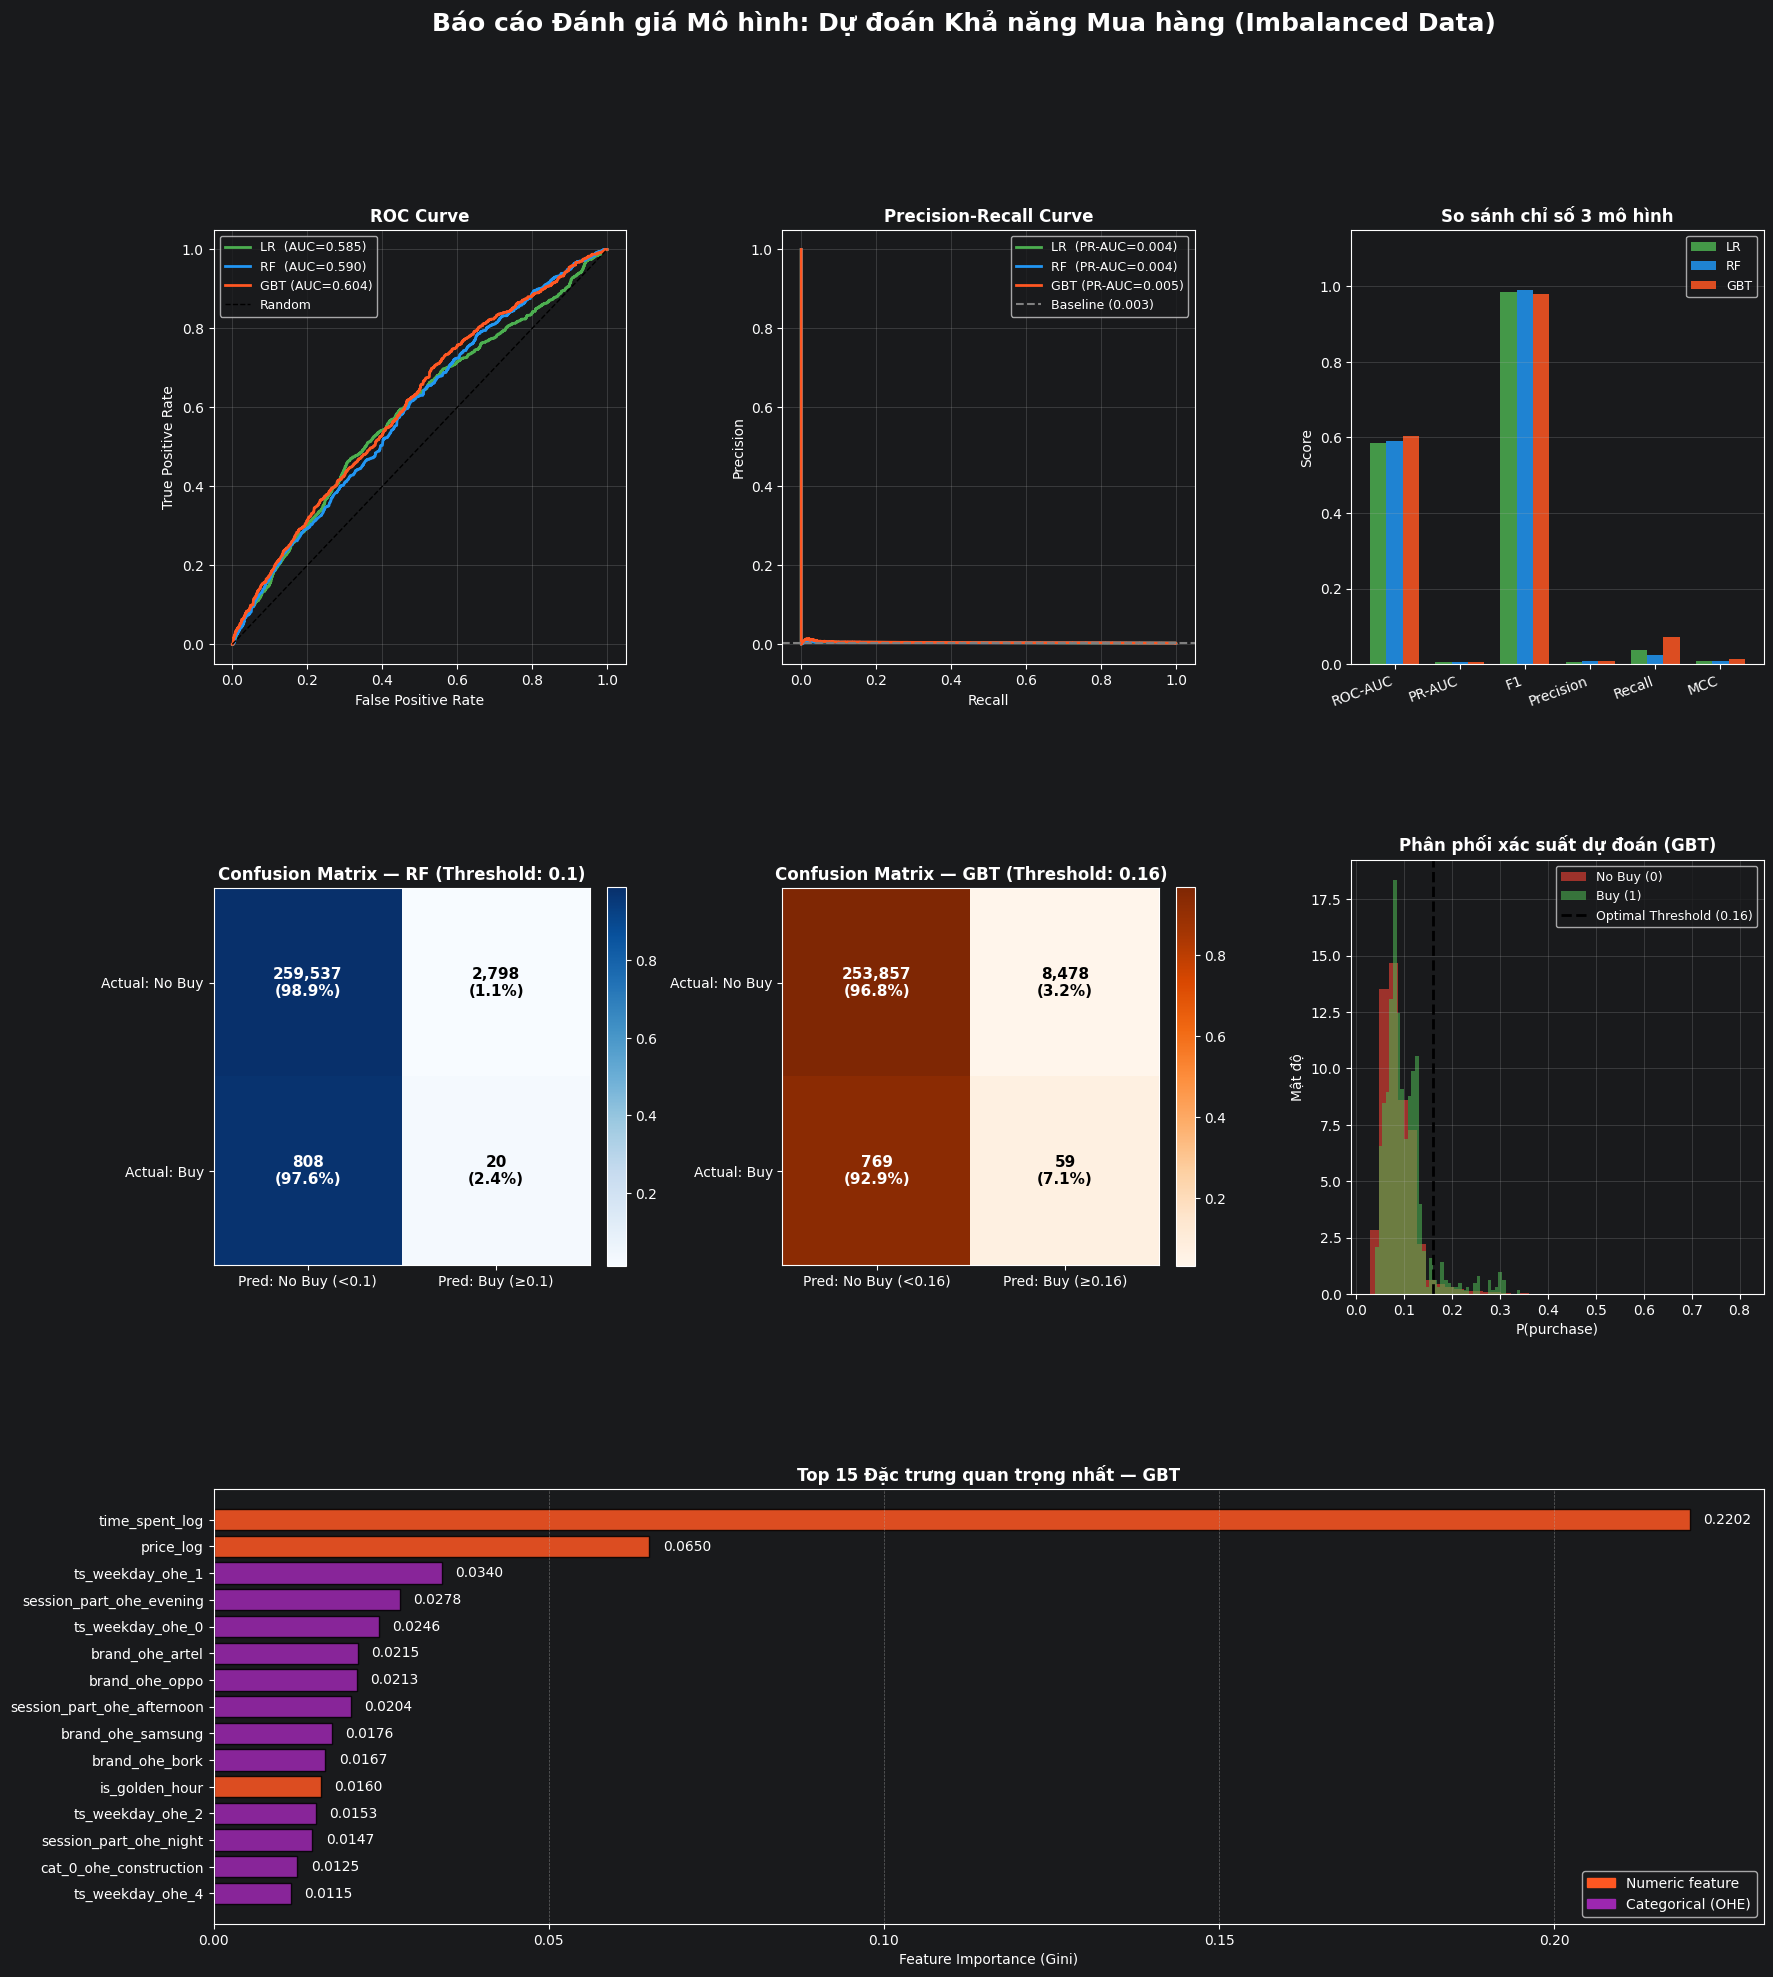

✓ Đã xuất bản Dashboard toàn diện và lưu file: executive_model_evaluation.png


In [48]:
print("=" * 80)
print("BƯỚC 16: TRỰC QUAN HÓA TOÀN DIỆN")
print("=" * 80)

# -------------------------------------------------------------------------
# 1. CHUẨN BỊ DỮ LIỆU
# -------------------------------------------------------------------------
pdf_lr = test_pred_lr_tuned.select("label", "prob_1", "prediction_tuned").toPandas()
pdf_rf = test_pred_rf_tuned.select("label", "prob_1", "prediction_tuned").toPandas()
pdf_gbt = test_pred_gbt_tuned.select("label", "prob_1", "prediction_tuned").toPandas()

cm_rf = confusion_matrix(pdf_rf["label"], pdf_rf["prediction_tuned"])
cm_gbt = confusion_matrix(pdf_gbt["label"], pdf_gbt["prediction_tuned"])

if 'feat_imp_df' in locals():
    top15_fi = feat_imp_df.head(15).copy()
else:
    top15_fi = pd.DataFrame(columns=["Feature", "Importance"])

# -------------------------------------------------------------------------
# 2. KHỞI TẠO DASHBOARD VÀ VẼ BIỂU ĐỒ
# -------------------------------------------------------------------------
fig = plt.figure(figsize=(20, 22))
fig.suptitle(
    "Báo cáo Đánh giá Mô hình: Dự đoán Khả năng Mua hàng (Imbalanced Data)",
    fontsize=18, fontweight="bold", y=0.98
)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.38)
COLORS = {"LR": "#4CAF50", "RF": "#2196F3", "GBT": "#FF5722", "pos": "#4CAF50", "neg": "#F44336"}

# --- BIỂU ĐỒ 1: ROC CURVE ---
ax1 = fig.add_subplot(gs[0, 0])
for pdf, label, color in [
    (pdf_lr,  f"LR  (AUC={metrics_lr['ROC-AUC']:.3f})",  COLORS["LR"]),
    (pdf_rf,  f"RF  (AUC={metrics_rf['ROC-AUC']:.3f})",  COLORS["RF"]),
    (pdf_gbt, f"GBT (AUC={metrics_gbt['ROC-AUC']:.3f})", COLORS["GBT"])
]:
    fpr, tpr, _ = roc_curve(pdf["label"], pdf["prob_1"])
    ax1.plot(fpr, tpr, color=color, lw=2, label=label)
ax1.plot([0,1],[0,1], "k--", lw=1, label="Random")
ax1.set_xlabel("False Positive Rate"); ax1.set_ylabel("True Positive Rate")
ax1.set_title("ROC Curve", fontweight="bold")
ax1.legend(fontsize=9); ax1.grid(alpha=0.3)

# --- BIỂU ĐỒ 2: PRECISION-RECALL CURVE ---
ax2 = fig.add_subplot(gs[0, 1])
for pdf, label, color in [
    (pdf_lr,  f"LR  (PR-AUC={metrics_lr['PR-AUC']:.3f})",  COLORS["LR"]),
    (pdf_rf,  f"RF  (PR-AUC={metrics_rf['PR-AUC']:.3f})",  COLORS["RF"]),
    (pdf_gbt, f"GBT (PR-AUC={metrics_gbt['PR-AUC']:.3f})", COLORS["GBT"])
]:
    prec, rec, _ = precision_recall_curve(pdf["label"], pdf["prob_1"])
    ax2.plot(rec, prec, color=color, lw=2, label=label)
baseline = pdf_gbt["label"].mean()
ax2.axhline(baseline, color="gray", ls="--", lw=1.5, label=f"Baseline ({baseline:.3f})")
ax2.set_xlabel("Recall"); ax2.set_ylabel("Precision")
ax2.set_title("Precision-Recall Curve", fontweight="bold")
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

# --- BIỂU ĐỒ 3: SO SÁNH CHỈ SỐ ĐÁNH GIÁ ---
ax3 = fig.add_subplot(gs[0, 2])
metrics_keys = ["ROC-AUC", "PR-AUC", "F1", "Precision", "Recall", "MCC"]
vals_lr  = [metrics_lr[k] for k in metrics_keys]
vals_rf  = [metrics_rf[k] for k in metrics_keys]
vals_gbt = [metrics_gbt[k] for k in metrics_keys]

x = np.arange(len(metrics_keys))
w = 0.25
ax3.bar(x - w, vals_lr,  w, label="LR",  color=COLORS["LR"],  alpha=0.85)
ax3.bar(x,     vals_rf,  w, label="RF",  color=COLORS["RF"],  alpha=0.85)
ax3.bar(x + w, vals_gbt, w, label="GBT", color=COLORS["GBT"], alpha=0.85)
ax3.set_xticks(x); ax3.set_xticklabels(metrics_keys, rotation=20, ha="right", fontsize=10)
ax3.set_ylim(0, 1.15); ax3.set_ylabel("Score")
ax3.set_title("So sánh chỉ số 3 mô hình", fontweight="bold")
ax3.legend(fontsize=9); ax3.grid(axis="y", alpha=0.3)

# --- BIỂU ĐỒ 4: CONFUSION MATRIX — RANDOM FOREST ---
ax4 = fig.add_subplot(gs[1, 0])
cm_norm_rf = cm_rf / cm_rf.sum(axis=1, keepdims=True)
im_rf = ax4.imshow(cm_norm_rf, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax4.text(j, i, f"{cm_rf[i,j]:,}\n({cm_norm_rf[i,j]:.1%})",
                 ha="center", va="center", fontsize=11, fontweight="bold",
                 color="white" if cm_norm_rf[i,j] > 0.5 else "black")
ax4.set_xticks([0,1]); ax4.set_yticks([0,1])
ax4.set_xticklabels([f"Pred: No Buy (<{thresh_rf})", f"Pred: Buy (≥{thresh_rf})"])
ax4.set_yticklabels(["Actual: No Buy","Actual: Buy"])
ax4.set_title(f"Confusion Matrix — RF (Threshold: {thresh_rf})", fontweight="bold")
plt.colorbar(im_rf, ax=ax4, fraction=0.046, pad=0.04)

# --- BIỂU ĐỒ 5: CONFUSION MATRIX — GBT ---
ax5 = fig.add_subplot(gs[1, 1])
cm_norm_gbt = cm_gbt / cm_gbt.sum(axis=1, keepdims=True)
im_gbt = ax5.imshow(cm_norm_gbt, cmap="Oranges")
for i in range(2):
    for j in range(2):
        ax5.text(j, i, f"{cm_gbt[i,j]:,}\n({cm_norm_gbt[i,j]:.1%})",
                 ha="center", va="center", fontsize=11, fontweight="bold",
                 color="white" if cm_norm_gbt[i,j] > 0.5 else "black")
ax5.set_xticks([0,1]); ax5.set_yticks([0,1])
ax5.set_xticklabels([f"Pred: No Buy (<{thresh_gbt})", f"Pred: Buy (≥{thresh_gbt})"])
ax5.set_yticklabels(["Actual: No Buy","Actual: Buy"])
ax5.set_title(f"Confusion Matrix — GBT (Threshold: {thresh_gbt})", fontweight="bold")
plt.colorbar(im_gbt, ax=ax5, fraction=0.046, pad=0.04)

# --- BIỂU ĐỒ 6: PHÂN PHỐI XÁC SUẤT DỰ ĐOÁN (GBT) ---
ax6 = fig.add_subplot(gs[1, 2])
for lbl, color, name in [(0, COLORS["neg"], "No Buy (0)"), (1, COLORS["pos"], "Buy (1)")]:
    subset = pdf_gbt[pdf_gbt["label"] == lbl]["prob_1"]
    ax6.hist(subset, bins=40, alpha=0.6, color=color, label=name, density=True)
ax6.axvline(thresh_gbt, color="black", ls="--", lw=2, label=f"Optimal Threshold ({thresh_gbt})")
ax6.set_xlabel("P(purchase)"); ax6.set_ylabel("Mật độ")
ax6.set_title("Phân phối xác suất dự đoán (GBT)", fontweight="bold")
ax6.legend(fontsize=9); ax6.grid(alpha=0.3)

# --- BIỂU ĐỒ 7: FEATURE IMPORTANCE (GBT) ---
if not top15_fi.empty:
    ax7 = fig.add_subplot(gs[2, :])
    colors_fi = [COLORS["GBT"] if "_ohe" not in str(f) else "#9C27B0" for f in top15_fi["Feature"]]

    features_rev = top15_fi["Feature"].values[::-1]
    importances_rev = top15_fi["Importance"].values[::-1]
    colors_rev = colors_fi[::-1]

    bars = ax7.barh(features_rev, importances_rev,
                    color=colors_rev, alpha=0.85, edgecolor="black")
    for bar, val in zip(bars, importances_rev):
        ax7.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                 f"{val:.4f}", va="center", fontsize=10)
    patch_num = mpatches.Patch(color=COLORS["GBT"],  label="Numeric feature")
    patch_cat = mpatches.Patch(color="#9C27B0",     label="Categorical (OHE)")
    ax7.legend(handles=[patch_num, patch_cat], fontsize=10)
    ax7.set_xlabel("Feature Importance (Gini)")
    ax7.set_title("Top 15 Đặc trưng quan trọng nhất — GBT", fontweight="bold")
    ax7.grid(axis="x", linestyle="--", alpha=0.5)

plt.savefig("executive_model_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Đã xuất bản Dashboard toàn diện và lưu file: executive_model_evaluation.png")

### Bước 17: Lưu mô hình

In [49]:
print("=" * 80)
print("BƯỚC 17: LƯU KẾT QUẢ DỰ ĐOÁN VÀ MÔ HÌNH VÀO HDFS")
print("=" * 80)

final_predictions = test_pred_gbt_tuned.select(
    "label",
    "prob_1",
    "prediction_tuned"
)

try:
    final_predictions.write.parquet("hdfs://master:9000/data/final_predictions.parquet", mode="overwrite")
    print("✓ Đã lưu thành công tập dữ liệu Predictions vào HDFS!")
except Exception as e:
    print("Xảy ra lỗi khi lưu dữ liệu dự đoán:", e)

try:
    best_gbt.write().overwrite().save("hdfs://master:9000/models/best_gbt_model")
    print("✓ Đã lưu thành công mô hình GBT tốt nhất vào HDFS!")
except Exception as e:
    print("Xảy ra lỗi khi lưu mô hình:", e)

BƯỚC 17: LƯU KẾT QUẢ DỰ ĐOÁN VÀ MÔ HÌNH VÀO HDFS
✓ Đã lưu thành công tập dữ liệu Predictions vào HDFS!
✓ Đã lưu thành công mô hình GBT tốt nhất vào HDFS!


### Bước 18: Đóng session

In [50]:
print("=" * 80)
print("BƯỚC 18: DỌN DẸP BỘ NHỚ VÀ ĐÓNG SPARK SESSION")
print("=" * 80)

# 1. Giải phóng bộ nhớ (Unpersist)
try:
    if 'test_prepared' in locals(): test_prepared.unpersist()
    if 'val_prepared' in locals(): val_prepared.unpersist()
    if 'train_prepared' in locals(): train_prepared.unpersist()
    if 'train_df' in locals(): train_df.unpersist()
    if 'val_df' in locals(): val_df.unpersist()
    if 'test_df' in locals(): test_df.unpersist()
    if 'train_with_meta' in locals(): train_with_meta.unpersist()
    print("✓ Đã giải phóng bộ nhớ (Unpersist) hoàn toàn cho các DataFrames.")
except Exception as e:
    print("Lỗi khi unpersist:", e)

# 2. Đóng Spark Session
try:
    spark.stop()
    print("✓ Đã đóng Spark Session thành công. Toàn bộ cluster được giải phóng!")
except Exception as e:
    print("Lỗi khi đóng Spark Session:", e)

BƯỚC 18: DỌN DẸP BỘ NHỚ VÀ ĐÓNG SPARK SESSION
✓ Đã giải phóng bộ nhớ (Unpersist) hoàn toàn cho các DataFrames.
✓ Đã đóng Spark Session thành công. Toàn bộ cluster được giải phóng!
